# 라이브러리 Import

In [6]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리 및 Feature Engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 설정
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ 라이브러리 Import 완료!")

✅ 라이브러리 Import 완료!


# 데이터 로드

In [7]:
# EDA에서 정제된 데이터 로드
df = pd.read_csv('../data/processed/churn_data_eda.csv')

print("="*60)
print("📊 데이터셋 정보 (EDA 정제 완료)")
print("="*60)
print(f"데이터 크기: {df.shape}")
print(f"컬럼 수: {df.shape[1]}")
print(f"행 수: {df.shape[0]:,}")

# 결측치 확인
missing = df.isnull().sum().sum()
print(f"\n총 결측치: {missing}개")

if missing == 0:
    print("✅ 결측치 없음 (EDA에서 이미 처리됨)")

# 데이터 타입 확인
print(f"\n데이터 타입:")
print(df.dtypes.value_counts())

print(f"\n처음 5개 행:")
df.head()

📊 데이터셋 정보 (EDA 정제 완료)
데이터 크기: (7043, 21)
컬럼 수: 21
행 수: 7,043

총 결측치: 0개
✅ 결측치 없음 (EDA에서 이미 처리됨)

데이터 타입:
object     17
int64       2
float64     2
Name: count, dtype: int64

처음 5개 행:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 카피

In [9]:
df_fe = df.copy()

In [10]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# 고유 ID drop
df_fe = df_fe.drop('customerID', axis=1)
# print(df_fe.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# 파생 변수 생성

In [13]:
#1. Tenure 관련 Features 

# 1-1. Tenure 그룹화
df_fe['tenure_group'] = pd.cut(
    df_fe['tenure'], 
    bins=[0, 12, 24, 48, 72],
    labels=['0-1년', '1-2년', '2-4년', '4년+']
)
print("   ✅ tenure_group: 재직 기간 그룹 (0-1년, 1-2년, 2-4년, 4년+)")

# 1-2. 신규 고객 여부 (6개월 이하)
df_fe['is_new_customer'] = (df_fe['tenure'] <= 6).astype(int)
print("   ✅ is_new_customer: 6개월 이하 신규 고객 (0/1)")

# 1-3. 장기 고객 여부 (48개월 이상)
df_fe['is_long_term'] = (df_fe['tenure'] >= 48).astype(int)
print("   ✅ is_long_term: 4년 이상 장기 고객 (0/1)")


# ===== 2. 요금 관련 Features =====
print("\n2️⃣ 요금 관련 Features")

# 2-1. 월평균 요금 (TotalCharges / Tenure)
df_fe['avg_monthly_charges'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)  # +1로 0 방지
print("   ✅ avg_monthly_charges: 월평균 요금")

# 2-2. 요금 증가율 (MonthlyCharges / avg_monthly_charges)
df_fe['charges_ratio'] = df_fe['MonthlyCharges'] / (df_fe['avg_monthly_charges'] + 0.01)
print("   ✅ charges_ratio: 현재 월요금 / 평균 월요금 비율")

# 2-3. 고액 결제 여부 (MonthlyCharges 상위 25%)
high_charge_threshold = df_fe['MonthlyCharges'].quantile(0.75)
df_fe['is_high_charge'] = (df_fe['MonthlyCharges'] >= high_charge_threshold).astype(int)
print(f"   ✅ is_high_charge: 월요금 ${high_charge_threshold:.2f} 이상 (0/1)")


# ===== 3. 서비스 이용 관련 Features =====
print("\n3️⃣ 서비스 이용 관련 Features")

# 3-1. 온라인 서비스 이용 개수
online_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
df_fe['num_online_services'] = (df_fe[online_services] == 'Yes').sum(axis=1)
print(f"   ✅ num_online_services: 온라인 서비스 이용 개수 (0-{len(online_services)})")

# 3-2. 추가 서비스 미이용 여부
df_fe['no_additional_services'] = (df_fe['num_online_services'] == 0).astype(int)
print("   ✅ no_additional_services: 추가 서비스 전혀 안 씀 (0/1)")

# 3-3. 전화/인터넷 둘 다 사용 여부
df_fe['has_phone_internet'] = (
    (df_fe['PhoneService'] == 'Yes') & 
    (df_fe['InternetService'] != 'No')
).astype(int)
print("   ✅ has_phone_internet: 전화+인터넷 모두 사용 (0/1)")


# ===== 4. 계약/결제 관련 Features =====
print("\n4️⃣ 계약/결제 관련 Features")

# 4-1. 단기 계약 여부
df_fe['is_month_to_month'] = (df_fe['Contract'] == 'Month-to-month').astype(int)
print("   ✅ is_month_to_month: 월 단위 계약 여부 (0/1)")

# 4-2. 자동 결제 여부
auto_payment = ['Bank transfer (automatic)', 'Credit card (automatic)']
df_fe['is_auto_payment'] = df_fe['PaymentMethod'].isin(auto_payment).astype(int)
print("   ✅ is_auto_payment: 자동 결제 여부 (0/1)")

# 4-3. 페이퍼리스 & 자동결제 조합
df_fe['paperless_auto_pay'] = (
    (df_fe['PaperlessBilling'] == 'Yes') & 
    (df_fe['is_auto_payment'] == 1)
).astype(int)
print("   ✅ paperless_auto_pay: 페이퍼리스 + 자동결제 (0/1)")


# ===== 5. 고객 특성 관련 Features =====
print("\n5️⃣ 고객 특성 관련 Features")

# 5-1. 가족 구성원 수
df_fe['num_dependents'] = (
    (df_fe['Partner'] == 'Yes').astype(int) + 
    (df_fe['Dependents'] == 'Yes').astype(int)
)
print("   ✅ num_dependents: 가족 구성원 수 (0-2)")

# 5-2. 독신 여부
df_fe['is_single'] = (
    (df_fe['Partner'] == 'No') & 
    (df_fe['Dependents'] == 'No')
).astype(int)
print("   ✅ is_single: 배우자/부양가족 없음 (0/1)")

# 5-3. 시니어 & 독신 조합 (고위험군)
df_fe['senior_single'] = (
    (df_fe['SeniorCitizen'] == 1) & 
    (df_fe['is_single'] == 1)
).astype(int)
print("   ✅ senior_single: 시니어 + 독신 (0/1)")


# ===== 6. 인터넷 서비스 관련 Features =====
print("\n6️⃣ 인터넷 서비스 관련 Features")

# 6-1. Fiber optic 사용 여부 (이탈률 높음)
df_fe['is_fiber_optic'] = (df_fe['InternetService'] == 'Fiber optic').astype(int)
print("   ✅ is_fiber_optic: Fiber optic 사용 여부 (0/1)")

# 6-2. 인터넷 서비스 없음
df_fe['no_internet'] = (df_fe['InternetService'] == 'No').astype(int)
print("   ✅ no_internet: 인터넷 서비스 미사용 (0/1)")


print("\n" + "="*60)
print(f"✅ Feature Engineering 완료!")
print(f"   기존 컬럼: {df.shape[1]}개")
print(f"   현재 컬럼: {df_fe.shape[1]}개")
print(f"   추가된 Feature: {df_fe.shape[1] - df.shape[1]}개")
print("="*60)

   ✅ tenure_group: 재직 기간 그룹 (0-1년, 1-2년, 2-4년, 4년+)
   ✅ is_new_customer: 6개월 이하 신규 고객 (0/1)
   ✅ is_long_term: 4년 이상 장기 고객 (0/1)

2️⃣ 요금 관련 Features
   ✅ avg_monthly_charges: 월평균 요금
   ✅ charges_ratio: 현재 월요금 / 평균 월요금 비율
   ✅ is_high_charge: 월요금 $89.85 이상 (0/1)

3️⃣ 서비스 이용 관련 Features
   ✅ num_online_services: 온라인 서비스 이용 개수 (0-6)
   ✅ no_additional_services: 추가 서비스 전혀 안 씀 (0/1)
   ✅ has_phone_internet: 전화+인터넷 모두 사용 (0/1)

4️⃣ 계약/결제 관련 Features
   ✅ is_month_to_month: 월 단위 계약 여부 (0/1)
   ✅ is_auto_payment: 자동 결제 여부 (0/1)
   ✅ paperless_auto_pay: 페이퍼리스 + 자동결제 (0/1)

5️⃣ 고객 특성 관련 Features
   ✅ num_dependents: 가족 구성원 수 (0-2)
   ✅ is_single: 배우자/부양가족 없음 (0/1)
   ✅ senior_single: 시니어 + 독신 (0/1)

6️⃣ 인터넷 서비스 관련 Features
   ✅ is_fiber_optic: Fiber optic 사용 여부 (0/1)
   ✅ no_internet: 인터넷 서비스 미사용 (0/1)

✅ Feature Engineering 완료!
   기존 컬럼: 21개
   현재 컬럼: 37개
   추가된 Feature: 16개


# 생성된 Feature 확인

In [14]:
# 새로 생성된 Feature 목록
new_features = [
    'tenure_group', 'is_new_customer', 'is_long_term',
    'avg_monthly_charges', 'charges_ratio', 'is_high_charge',
    'num_online_services', 'no_additional_services', 'has_phone_internet',
    'is_month_to_month', 'is_auto_payment', 'paperless_auto_pay',
    'num_dependents', 'is_single', 'senior_single',
    'is_fiber_optic', 'no_internet'
]

print("="*60)
print("📊 새로 생성된 Features")
print("="*60)

for i, feat in enumerate(new_features, 1):
    print(f"{i:2d}. {feat:25s} - {df_fe[feat].dtype}")

# 몇 가지 Feature 샘플 데이터 확인
print("\n샘플 데이터 (처음 5개 행):")
print(df_fe[new_features].head())

📊 새로 생성된 Features
 1. tenure_group              - category
 2. is_new_customer           - int32
 3. is_long_term              - int32
 4. avg_monthly_charges       - float64
 5. charges_ratio             - float64
 6. is_high_charge            - int32
 7. num_online_services       - int64
 8. no_additional_services    - int32
 9. has_phone_internet        - int32
10. is_month_to_month         - int32
11. is_auto_payment           - int32
12. paperless_auto_pay        - int32
13. num_dependents            - int32
14. is_single                 - int32
15. senior_single             - int32
16. is_fiber_optic            - int32
17. no_internet               - int32

샘플 데이터 (처음 5개 행):
  tenure_group  is_new_customer  is_long_term  avg_monthly_charges  \
0         0-1년                1             0            14.925000   
1         2-4년                0             0            53.985714   
2         0-1년                1             0            36.050000   
3         2-4년                

# Feature별 이탈률 분석

📈 새로운 Feature별 이탈률 분석
               Feature  Churn_Rate (%)
       is_new_customer       52.937205
         senior_single       49.197861
     is_month_to_month       42.709677
        is_fiber_optic       41.892765
             is_single       34.237805
    has_phone_internet       32.802482
        is_high_charge       32.749859
no_additional_services       21.406039
    paperless_auto_pay       19.966159
       is_auto_payment       15.981735
          is_long_term        9.639601
           no_internet        7.404980


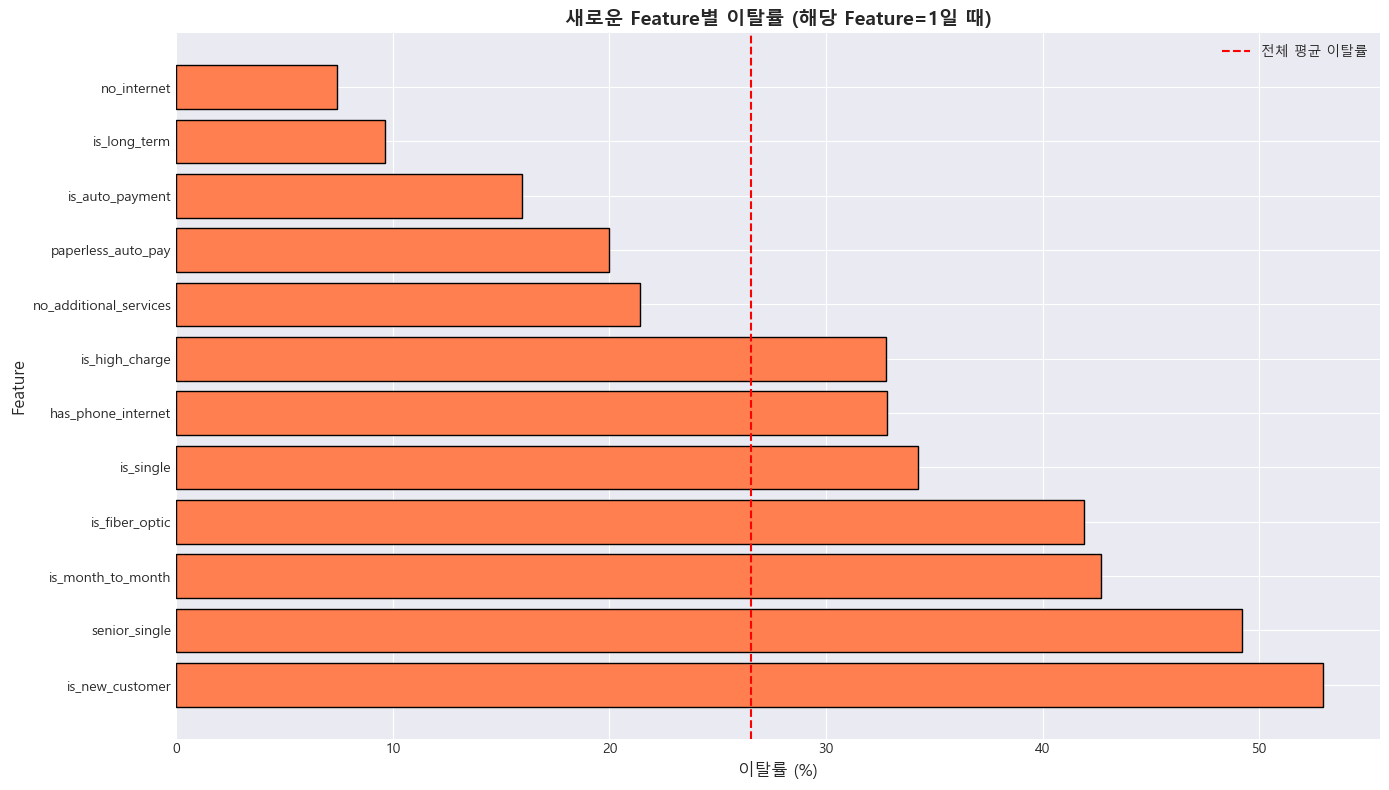

In [16]:
print("="*60)
print("📈 새로운 Feature별 이탈률 분석")
print("="*60)

# 이진 Feature들의 이탈률 비교
binary_features = [
    'is_new_customer', 'is_long_term', 'is_high_charge',
    'no_additional_services', 'has_phone_internet',
    'is_month_to_month', 'is_auto_payment', 'paperless_auto_pay',
    'is_single', 'senior_single', 'is_fiber_optic', 'no_internet'
]

churn_rates = []

for feat in binary_features:
    churn_rate = df_fe.groupby(feat)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    if 1 in churn_rate.index:
        rate_yes = churn_rate[1]
        churn_rates.append({'Feature': feat, 'Churn_Rate (%)': rate_yes})

# 데이터프레임으로 변환 및 정렬
churn_df = pd.DataFrame(churn_rates).sort_values('Churn_Rate (%)', ascending=False)

print(churn_df.to_string(index=False))

# 시각화
plt.figure(figsize=(14, 8))
plt.barh(churn_df['Feature'], churn_df['Churn_Rate (%)'], color='coral', edgecolor='black')
plt.xlabel('이탈률 (%)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('새로운 Feature별 이탈률 (해당 Feature=1일 때)', fontsize=14, fontweight='bold')
plt.axvline(x=df_fe[df_fe['Churn']=='Yes'].shape[0]/len(df_fe)*100, 
            color='red', linestyle='--', label='전체 평균 이탈률')
plt.legend()
plt.tight_layout()
plt.show()

💡 인사이트:
- is_new_customer (신규 고객): 이탈률 가장 높음
- is_month_to_month (단기 계약): 이탈 위험 높음
- is_fiber_optic: 이탈 위험 높음
- is_long_term (장기 고객): 이탈률 낮음 (안전)

# 수치형 Feature 분포 시각화

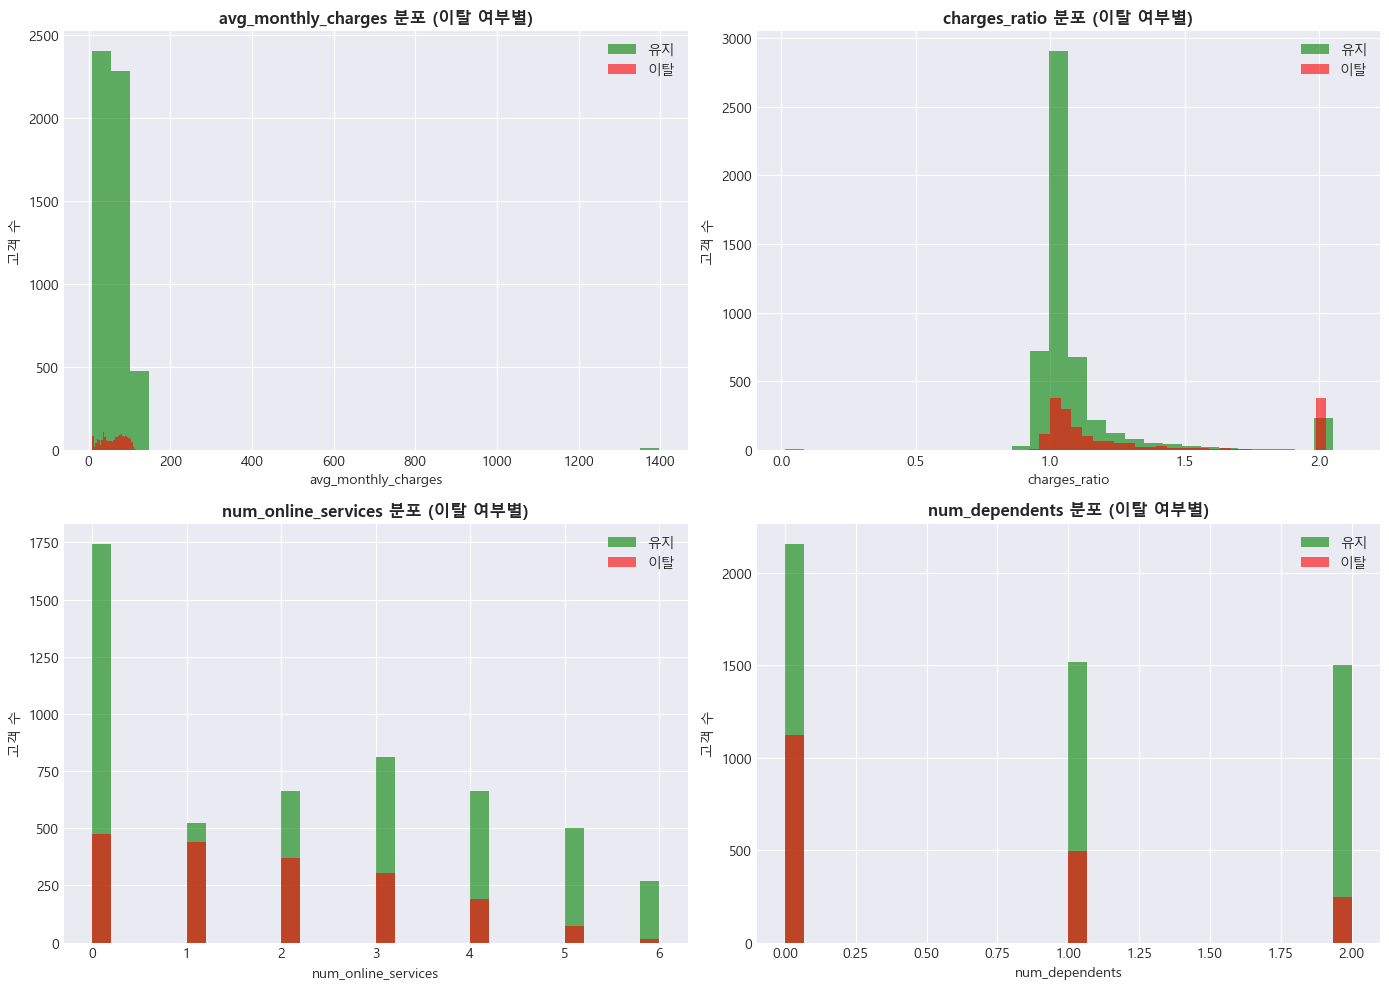

In [ ]:
# 수치형 새 Feature 분포
numeric_new_features = ['avg_monthly_charges', 'charges_ratio', 'num_online_services', 'num_dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feat in enumerate(numeric_new_features):
    # 이탈 여부별 히스토그램
    df_fe[df_fe['Churn'] == 'No'][feat].hist(bins=30, alpha=0.6,label='유지', color='green', ax=axes[idx])
    df_fe[df_fe['Churn'] == 'Yes'][feat].hist(bins=30, alpha=0.6,label='이탈', color='red', ax=axes[idx])
    axes[idx].set_title(f'{feat} 분포 (이탈 여부별)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feat, fontsize=10)
    axes[idx].set_ylabel('고객 수', fontsize=10)
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Feature 중요도 사전 분석 (Chi-Square Test)

📊 Feature 중요도 사전 분석 (Chi-Square Test)
               Feature  Chi-Square Score       P-value
       is_new_customer        529.480194 3.664675e-117
     is_month_to_month        519.895311 4.459832e-115
        is_fiber_optic        374.476216  1.984260e-83
          is_long_term        337.297147  2.474632e-75
           no_internet        286.520193  2.849642e-64
       is_auto_payment        175.222151  5.354202e-40
         senior_single        147.773248  5.317386e-34
             is_single         99.776253  1.706238e-23
    has_phone_internet         97.361416  5.776068e-23
    paperless_auto_pay         39.267078  3.696212e-10
        is_high_charge         35.065739  3.187602e-09
no_additional_services         29.966239  4.396346e-08


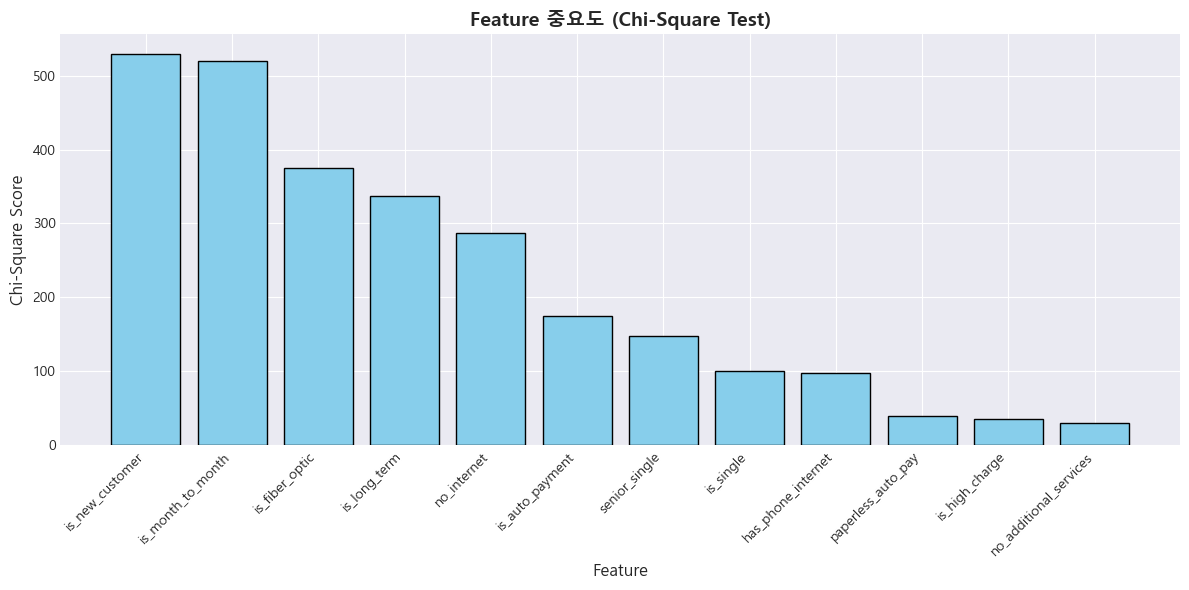


💡 p-value < 0.05인 유의미한 Features:
['is_new_customer', 'is_month_to_month', 'is_fiber_optic', 'is_long_term', 'no_internet', 'is_auto_payment', 'senior_single', 'is_single', 'has_phone_internet', 'paperless_auto_pay', 'is_high_charge', 'no_additional_services']


In [18]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

print("="*60)
print("📊 Feature 중요도 사전 분석 (Chi-Square Test)")
print("="*60)

# Target 변수 인코딩
y = df_fe['Churn'].map({'Yes': 1, 'No': 0})

# 범주형 변수 선택
categorical_features = [
    'is_new_customer', 'is_long_term', 'is_high_charge',
    'no_additional_services', 'has_phone_internet',
    'is_month_to_month', 'is_auto_payment', 'paperless_auto_pay',
    'is_single', 'senior_single', 'is_fiber_optic', 'no_internet'
]

# Chi-Square 테스트
X_cat = df_fe[categorical_features]
chi_scores, p_values = chi2(X_cat, y)

# 결과 정리
feature_importance = pd.DataFrame({
    'Feature': categorical_features,
    'Chi-Square Score': chi_scores,
    'P-value': p_values
}).sort_values('Chi-Square Score', ascending=False)

print(feature_importance.to_string(index=False))

# 시각화
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importance)), feature_importance['Chi-Square Score'], 
        color='skyblue', edgecolor='black')
plt.xticks(range(len(feature_importance)), feature_importance['Feature'], rotation=45, ha='right')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Chi-Square Score', fontsize=12)
plt.title('Feature 중요도 (Chi-Square Test)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 p-value < 0.05인 유의미한 Features:")
significant = feature_importance[feature_importance['P-value'] < 0.05]
print(significant['Feature'].tolist())

# 데이터 인코딩 (모델링 준비)

In [19]:
print("="*60)
print("🔤 데이터 인코딩 시작")
print("="*60)

# 데이터 복사
df_encoded = df_fe.copy()

# 1. Target 변수 인코딩
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
print("✅ Target 변수 (Churn) 인코딩 완료")

# 2. 이진 변수 인코딩
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
label_encoders = {}

for col in binary_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le

print(f"✅ 이진 변수 {len(binary_cols)}개 인코딩 완료")

# 3. 다중 범주형 변수 → One-Hot Encoding
categorical_cols = [
    'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 
    'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

print(f"\n인코딩 전 컬럼 수: {df_encoded.shape[1]}")
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)
print(f"인코딩 후 컬럼 수: {df_encoded.shape[1]}")

# 4. tenure_group도 One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=['tenure_group'], drop_first=True)

print(f"\n✅ 최종 데이터 크기: {df_encoded.shape}")
print("✅ 모든 인코딩 완료!")

🔤 데이터 인코딩 시작
✅ Target 변수 (Churn) 인코딩 완료
✅ 이진 변수 5개 인코딩 완료

인코딩 전 컬럼 수: 37
인코딩 후 컬럼 수: 48

✅ 최종 데이터 크기: (7043, 50)
✅ 모든 인코딩 완료!


# 데이터 분할 및 스케일링

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("="*60)
print("🔀 데이터 분할 및 스케일링")
print("="*60)

# X, y 분리
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features 개수: {X.shape[1]}")
print(f"샘플 개수: {len(X)}")
print(f"이탈률: {y.mean():.2%}")

# Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # 이탈 비율 유지
)

print(f"\n✅ 학습 데이터: {X_train.shape}")
print(f"✅ 테스트 데이터: {X_test.shape}")

# 수치형 컬럼 스케일링
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 
                'avg_monthly_charges', 'charges_ratio']
numeric_cols = [col for col in numeric_cols if col in X.columns]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"\n✅ {len(numeric_cols)}개 수치형 컬럼 스케일링 완료")

🔀 데이터 분할 및 스케일링
Features 개수: 49
샘플 개수: 7043
이탈률: 26.54%

✅ 학습 데이터: (5634, 49)
✅ 테스트 데이터: (1409, 49)

✅ 5개 수치형 컬럼 스케일링 완료


# 전처리된 데이터 저장

In [22]:
import joblib
import os

print("="*60)
print("💾 전처리된 데이터 저장")
print("="*60)

# 디렉토리 생성
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# 데이터 저장
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# 스케일러 저장
joblib.dump(scaler, '../models/scaler.pkl')

# Feature 이름 저장
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("✅ 저장 완료:")
print("   - data/processed/X_train.csv")
print("   - data/processed/X_test.csv")
print("   - data/processed/y_train.csv")
print("   - data/processed/y_test.csv")
print("   - models/scaler.pkl")
print("   - models/feature_names.pkl")

💾 전처리된 데이터 저장
✅ 저장 완료:
   - data/processed/X_train.csv
   - data/processed/X_test.csv
   - data/processed/y_train.csv
   - data/processed/y_test.csv
   - models/scaler.pkl
   - models/feature_names.pkl


# Feature Engineering 요약

In [23]:
print("="*60)
print("📊 Feature Engineering 요약")
print("="*60)

summary = f"""
✅ 완료된 작업:

1️⃣ 기본 전처리
   - TotalCharges 결측치 처리
   - customerID 제거

2️⃣ 새로운 Feature 생성 (17개)
   - Tenure 관련: tenure_group, is_new_customer, is_long_term
   - 요금 관련: avg_monthly_charges, charges_ratio, is_high_charge
   - 서비스 관련: num_online_services, no_additional_services, has_phone_internet
   - 계약/결제: is_month_to_month, is_auto_payment, paperless_auto_pay
   - 고객 특성: num_dependents, is_single, senior_single
   - 인터넷: is_fiber_optic, no_internet

3️⃣ 데이터 인코딩
   - Target 변수: Yes/No → 1/0
   - 이진 변수: Label Encoding
   - 다중 범주형: One-Hot Encoding

4️⃣ 데이터 분할
   - 학습 데이터: {X_train.shape[0]:,}개 ({X_train.shape[0]/len(X)*100:.1f}%)
   - 테스트 데이터: {X_test.shape[0]:,}개 ({X_test.shape[0]/len(X)*100:.1f}%)

5️⃣ Feature 스케일링
   - StandardScaler 적용
   - 수치형 변수 {len(numeric_cols)}개

📈 최종 Feature 개수: {X_train.shape[1]}개

🎯 다음 단계: 모델 학습 (python src/train.py)
"""

print(summary)

print("="*60)
print("✅ Feature Engineering 완료!")
print("="*60)

📊 Feature Engineering 요약

✅ 완료된 작업:

1️⃣ 기본 전처리
   - TotalCharges 결측치 처리
   - customerID 제거

2️⃣ 새로운 Feature 생성 (17개)
   - Tenure 관련: tenure_group, is_new_customer, is_long_term
   - 요금 관련: avg_monthly_charges, charges_ratio, is_high_charge
   - 서비스 관련: num_online_services, no_additional_services, has_phone_internet
   - 계약/결제: is_month_to_month, is_auto_payment, paperless_auto_pay
   - 고객 특성: num_dependents, is_single, senior_single
   - 인터넷: is_fiber_optic, no_internet

3️⃣ 데이터 인코딩
   - Target 변수: Yes/No → 1/0
   - 이진 변수: Label Encoding
   - 다중 범주형: One-Hot Encoding

4️⃣ 데이터 분할
   - 학습 데이터: 5,634개 (80.0%)
   - 테스트 데이터: 1,409개 (20.0%)

5️⃣ Feature 스케일링
   - StandardScaler 적용
   - 수치형 변수 5개

📈 최종 Feature 개수: 49개

🎯 다음 단계: 모델 학습 (python src/train.py)

✅ Feature Engineering 완료!


# 생성된 Feature 중요도 미리보기

🌲 Random Forest로 Feature Importance 미리보기

🔝 Top 20 중요 Features:
                       Feature  Importance
                 charges_ratio    0.114859
             is_month_to_month    0.113643
                  TotalCharges    0.083693
                        tenure    0.083210
                MonthlyCharges    0.071437
           avg_monthly_charges    0.064983
                is_fiber_optic    0.056755
   InternetService_Fiber optic    0.035997
PaymentMethod_Electronic check    0.034869
               is_new_customer    0.025526
             Contract_Two year    0.022837
                  is_long_term    0.015388
           num_online_services    0.015119
              PaperlessBilling    0.014632
              tenure_group_4년+    0.012510
                num_dependents    0.012006
            OnlineSecurity_Yes    0.011633
               is_auto_payment    0.011545
             MultipleLines_Yes    0.010575
               TechSupport_Yes    0.010317


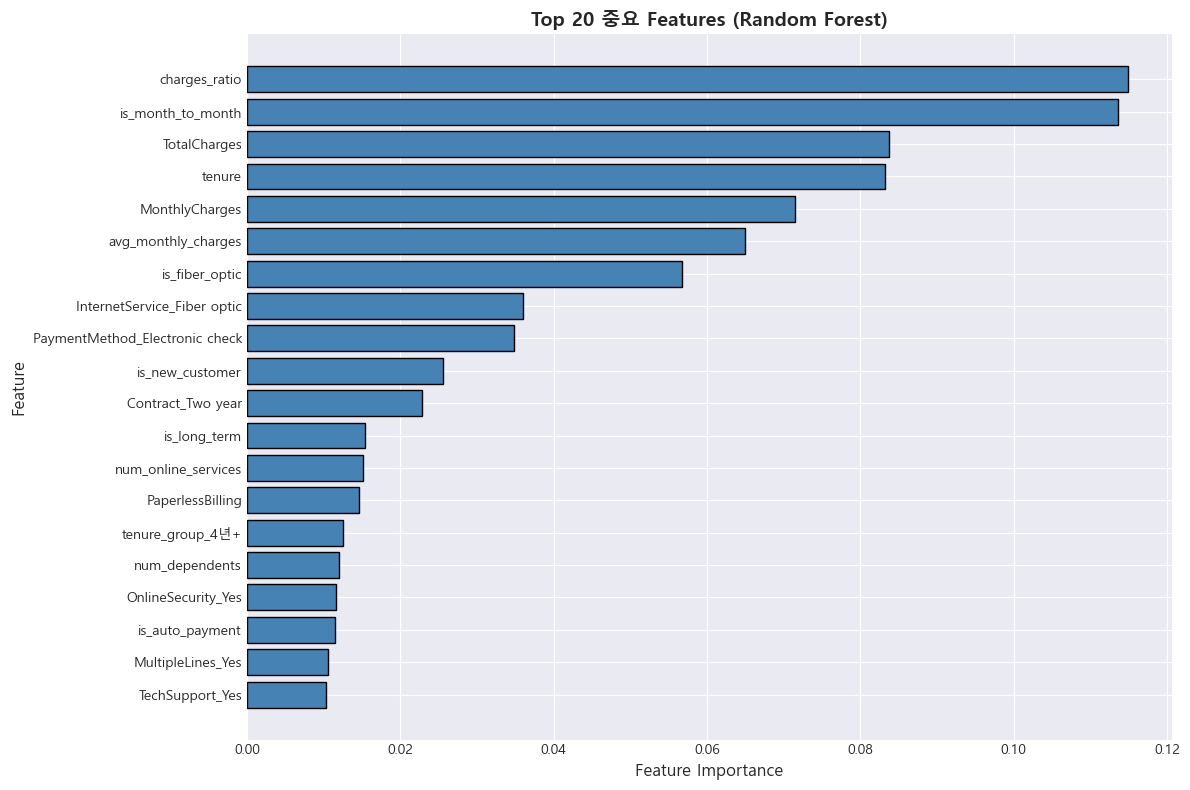

In [25]:
# 간단한 Random Forest로 Feature Importance 확인
from sklearn.ensemble import RandomForestClassifier

print("="*60)
print("🌲 Random Forest로 Feature Importance 미리보기")
print("="*60)

# 빠른 학습을 위해 간단한 모델
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Feature Importance 추출
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# 상위 20개 출력
print("\n🔝 Top 20 중요 Features:")
print(feature_importance.head(20).to_string(index=False))

# 시각화
plt.figure(figsize=(12, 8))
top_20 = feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 중요 Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


🌲 Random Forest로 Feature Importance 미리보기

🔝 Top 20 중요 Features:
                       Feature  Importance
                 charges_ratio    0.096809
                        tenure    0.096133
                  TotalCharges    0.088590
             is_month_to_month    0.086192
                MonthlyCharges    0.074741
           avg_monthly_charges    0.070540
                is_fiber_optic    0.048935
   InternetService_Fiber optic    0.043585
PaymentMethod_Electronic check    0.035268
               is_new_customer    0.031537
             Contract_Two year    0.026376
           num_online_services    0.017412
                  is_long_term    0.016325
              PaperlessBilling    0.015703
            OnlineSecurity_Yes    0.014611
              tenure_group_4년+    0.013586
               TechSupport_Yes    0.011939
                num_dependents    0.011544
             Contract_One year    0.011252
               is_auto_payment    0.010872


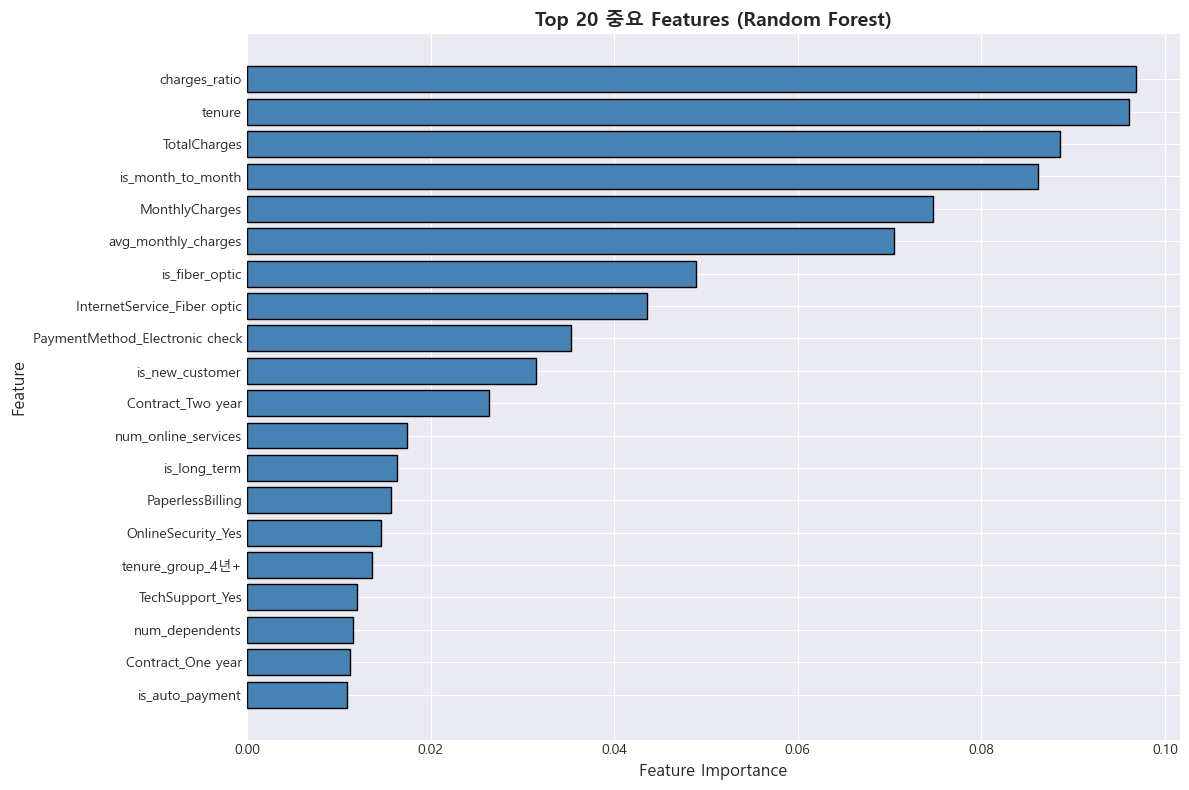

In [ ]:
# 간단한 Random Forest로 Feature Importance 확인
from sklearn.ensemble import RandomForestClassifier

print("="*60)
print("🌲 Random Forest로 Feature Importance 미리보기")
print("="*60)

# 빠른 학습을 위해 간단한 모델
rf = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=123, n_jobs=-1)
rf.fit(X_train, y_train)

# Feature Importance 추출
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# 상위 20개 출력
print("\n🔝 Top 20 중요 Features:")
print(feature_importance.head(20).to_string(index=False))

# 시각화
plt.figure(figsize=(12, 8))
top_20 = feature_importance.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 중요 Features (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
